# 04 — Evaluasi
**Project**: YOLOv11s Person Detection  
**Tujuan**: Evaluasi model terbaik pada test set — mAP, IoU, Confidence Score, PR Curve

> ⚠️ **Test set hanya digunakan sekali di sini, setelah tuning selesai.** Jangan jalankan notebook ini sebelum tuning selesai kecuali untuk evaluasi awal.

---

## 4.1 Import Libraries

In [7]:
%matplotlib inline
import torch
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from pathlib import Path
from PIL import Image
from ultralytics import YOLO

sns.set_theme(style='whitegrid')

# Load training summary
with open('runs/training_summary.json') as f:
    train_summary = json.load(f)

BEST_MODEL_PATH = train_summary['model_path']
DATASET_YAML    = 'dataset/dataset.yaml'
DEVICE          = 0 if torch.cuda.is_available() else 'cpu'
IMGSZ           = 640
CONF_THRESH     = 0.25
IOU_THRESH      = 0.5

# Direktori output evaluasi (dibuat otomatis)
EVAL_DIR = Path('runs/eval/test_eval')
EVAL_DIR.mkdir(parents=True, exist_ok=True)

print(f'Model terbaik : {BEST_MODEL_PATH}')
print(f'Device        : {DEVICE}')
print(f'Val mAP@0.5 (training): {train_summary["best_map50"]:.4f}')
print(f'Eval dir      : {EVAL_DIR}')


Model terbaik : runs\detect\runs\train\person_yolo11s_v1\weights\best.pt
Device        : 0
Val mAP@0.5 (training): 0.7306
Eval dir      : runs\eval\test_eval


## 4.2 Load Model Terbaik

In [8]:
model = YOLO(BEST_MODEL_PATH)
print(f'Model berhasil di-load dari: {BEST_MODEL_PATH}')
model.info()

Model berhasil di-load dari: runs\detect\runs\train\person_yolo11s_v1\weights\best.pt
YOLO11s summary: 182 layers, 9,428,179 parameters, 0 gradients, 21.5 GFLOPs


(182, 9428179, 0, 21.548492800000002)

## 4.3 Evaluasi pada Test Set

In [9]:
print('Menjalankan evaluasi pada TEST SET...')

test_metrics = model.val(
    data      = DATASET_YAML,
    split     = 'test',
    imgsz     = IMGSZ,
    batch     = 16,
    device    = DEVICE,
    conf      = CONF_THRESH,
    iou       = IOU_THRESH,
    plots     = True,
    save_json = True,
    project   = 'runs/eval',
    name      = 'test_eval',
    verbose   = True
)

print('\nEvaluasi selesai!')

Menjalankan evaluasi pada TEST SET...
Ultralytics 8.4.6  Python-3.12.10 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLO11s summary (fused): 101 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1471.1414.0 MB/s, size: 156.6 KB)
val: Scanning C:\NaufalFirdaus\CODES\AI\person-tracker-yolov11\files\dataset\labels\test.cache... 450 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 450/450  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 6.6it/s 4.4s0.1s
                   all        450       1963      0.778      0.654      0.755      0.535
Speed: 0.8ms preprocess, 6.0ms inference, 0.0ms loss, 0.5ms postprocess per image
Saving C:\NaufalFirdaus\CODES\AI\person-tracker-yolov11\files\runs\detect\runs\eval\test_eval2\predictions.json...
Results saved to C:\NaufalFirdaus\CODES\AI\person-tracker-yolov11\files\runs\detect\runs\eval\test_eval2



## 4.4 Hasil Metrik Utama

In [10]:
# Ekstrak metrik
map50     = test_metrics.box.map50
map5095   = test_metrics.box.map
precision = test_metrics.box.mp
recall    = test_metrics.box.mr
f1        = 2 * (precision * recall) / (precision + recall + 1e-8)

# Load baseline
with open('runs/baseline_results.json') as f:
    baseline = json.load(f)

print('=' * 60)
print('               HASIL EVALUASI — TEST SET')
print('=' * 60)
print(f'{"Metrik":25s} {"Baseline":>10s} {"Fine-tuned":>12s} {"Delta":>8s}')
print('-' * 60)
print(f'{"mAP@0.5":25s} {baseline["map50"]:>10.4f} {map50:>12.4f} {map50-baseline["map50"]:>+8.4f}')
print(f'{"mAP@0.5:0.95":25s} {baseline["map5095"]:>10.4f} {map5095:>12.4f} {map5095-baseline["map5095"]:>+8.4f}')
print(f'{"Precision":25s} {baseline["precision"]:>10.4f} {precision:>12.4f} {precision-baseline["precision"]:>+8.4f}')
print(f'{"Recall":25s} {baseline["recall"]:>10.4f} {recall:>12.4f} {recall-baseline["recall"]:>+8.4f}')
print(f'{"F1 Score":25s} {"—":>10s} {f1:>12.4f} {"—":>8s}')
print('=' * 60)
print(f'\nTarget mAP@0.5 ≥ 0.60: {"TERCAPAI ✓" if map50 >= 0.60 else "BELUM TERCAPAI ✗"}')
if map50 < 0.60:
    print('→ Lanjutkan ke notebook 05_tuning.ipynb')
else:
    print('→ Lanjutkan ke notebook 06_visualization.ipynb')

# Simpan eval result
eval_results = {
    'test_map50'    : float(map50),
    'test_map5095'  : float(map5095),
    'test_precision': float(precision),
    'test_recall'   : float(recall),
    'test_f1'       : float(f1),
    'target_achieved': bool(map50 >= 0.60)
}
with open('runs/eval_results.json', 'w') as f:
    json.dump(eval_results, f, indent=2)
print('\nHasil evaluasi tersimpan ke runs/eval_results.json')

               HASIL EVALUASI — TEST SET
Metrik                      Baseline   Fine-tuned    Delta
------------------------------------------------------------
mAP@0.5                       0.8213       0.7551  -0.0663
mAP@0.5:0.95                  0.6427       0.5348  -0.1079
Precision                     0.8386       0.7784  -0.0602
Recall                        0.7293       0.6536  -0.0757
F1 Score                           —       0.7106        —

Target mAP@0.5 ≥ 0.60: TERCAPAI ✓
→ Lanjutkan ke notebook 06_visualization.ipynb

Hasil evaluasi tersimpan ke runs/eval_results.json


## 4.5 Analisis IoU Distribution

In [11]:
from ultralytics.utils.metrics import box_iou
import torch

test_img_dir = Path('dataset/images/test')
test_lbl_dir = Path('dataset/labels/test')
test_images  = list(test_img_dir.glob('*.jpg'))

all_ious = []

print(f'Menghitung IoU dari {min(200, len(test_images))} gambar test...')

for img_path in test_images[:200]:   # Ambil 200 sampel untuk efisiensi
    lbl_path = test_lbl_dir / (img_path.stem + '.txt')
    if not lbl_path.exists():
        continue

    # Jalankan inference
    result = model.predict(
        source=str(img_path),
        conf=CONF_THRESH,
        iou=IOU_THRESH,
        imgsz=IMGSZ,
        device=DEVICE,
        verbose=False
    )[0]

    img = Image.open(img_path)
    img_w, img_h = img.size

    # Load ground truth
    gt_boxes = []
    with open(lbl_path) as f:
        for line in f:
            cls, xc, yc, wn, hn = map(float, line.strip().split())
            x1 = (xc - wn/2) * img_w
            y1 = (yc - hn/2) * img_h
            x2 = (xc + wn/2) * img_w
            y2 = (yc + hn/2) * img_h
            gt_boxes.append([x1, y1, x2, y2])

    if not gt_boxes or result.boxes is None or len(result.boxes) == 0:
        continue

    pred_boxes = result.boxes.xyxy.cpu()
    gt_tensor  = torch.tensor(gt_boxes, dtype=torch.float32)

    iou_matrix = box_iou(gt_tensor, pred_boxes)
    if iou_matrix.numel() > 0:
        max_ious = iou_matrix.max(dim=1).values.numpy()
        all_ious.extend(max_ious.tolist())

all_ious = np.array(all_ious)
print(f'Total pasangan GT-Pred yang dianalisis: {len(all_ious)}')

Menghitung IoU dari 200 gambar test...
Total pasangan GT-Pred yang dianalisis: 862


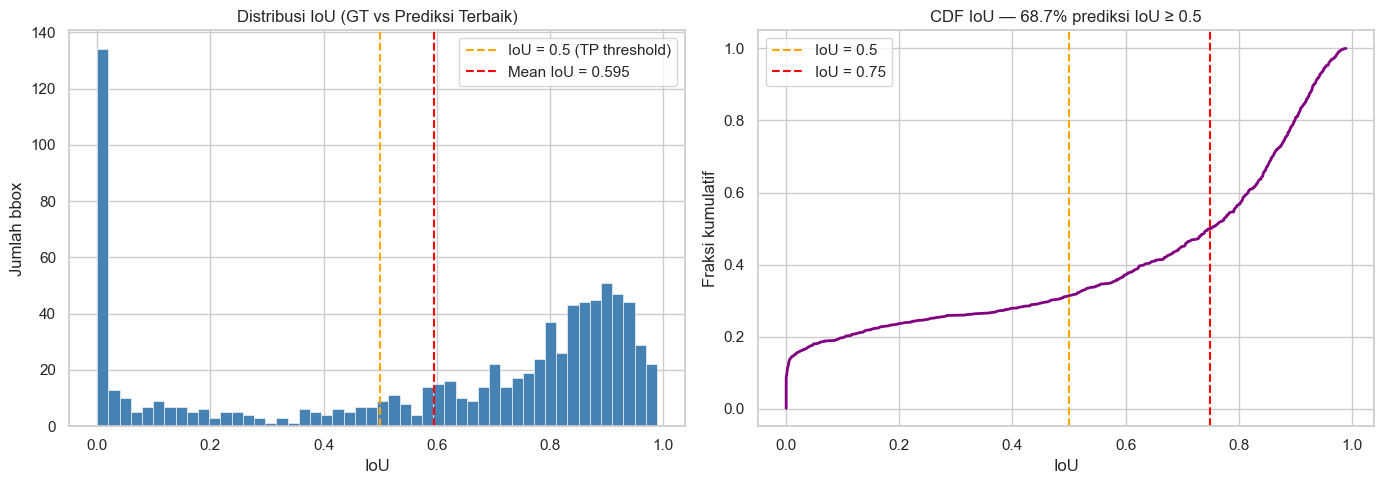

Statistik IoU:
  Mean IoU    : 0.5952
  Median IoU  : 0.7512
  IoU ≥ 0.50  : 68.7% prediksi
  IoU ≥ 0.75  : 50.1% prediksi
  IoU ≥ 0.90  : 19.7% prediksi


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram IoU
ax = axes[0]
ax.hist(all_ious, bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(0.5,  color='orange', linestyle='--', linewidth=1.5, label='IoU = 0.5 (TP threshold)')
ax.axvline(all_ious.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean IoU = {all_ious.mean():.3f}')
ax.set_xlabel('IoU')
ax.set_ylabel('Jumlah bbox')
ax.set_title('Distribusi IoU (GT vs Prediksi Terbaik)')
ax.legend()

# Kumulatif
ax = axes[1]
sorted_ious = np.sort(all_ious)
cumulative  = np.arange(1, len(sorted_ious)+1) / len(sorted_ious)
ax.plot(sorted_ious, cumulative, color='purple', linewidth=2)
ax.axvline(0.5, color='orange', linestyle='--', linewidth=1.5, label='IoU = 0.5')
ax.axvline(0.75, color='red', linestyle='--', linewidth=1.5, label='IoU = 0.75')
frac_above_50 = (all_ious >= 0.5).mean()
ax.set_xlabel('IoU')
ax.set_ylabel('Fraksi kumulatif')
ax.set_title(f'CDF IoU — {frac_above_50*100:.1f}% prediksi IoU ≥ 0.5')
ax.legend()

plt.tight_layout()
plt.savefig(EVAL_DIR / 'iou_distribution.png', dpi=100)
plt.show()

print(f'Statistik IoU:')
print(f'  Mean IoU    : {all_ious.mean():.4f}')
print(f'  Median IoU  : {np.median(all_ious):.4f}')
print(f'  IoU ≥ 0.50  : {(all_ious >= 0.50).mean()*100:.1f}% prediksi')
print(f'  IoU ≥ 0.75  : {(all_ious >= 0.75).mean()*100:.1f}% prediksi')
print(f'  IoU ≥ 0.90  : {(all_ious >= 0.90).mean()*100:.1f}% prediksi')


## 4.6 Analisis Confidence Score Distribution

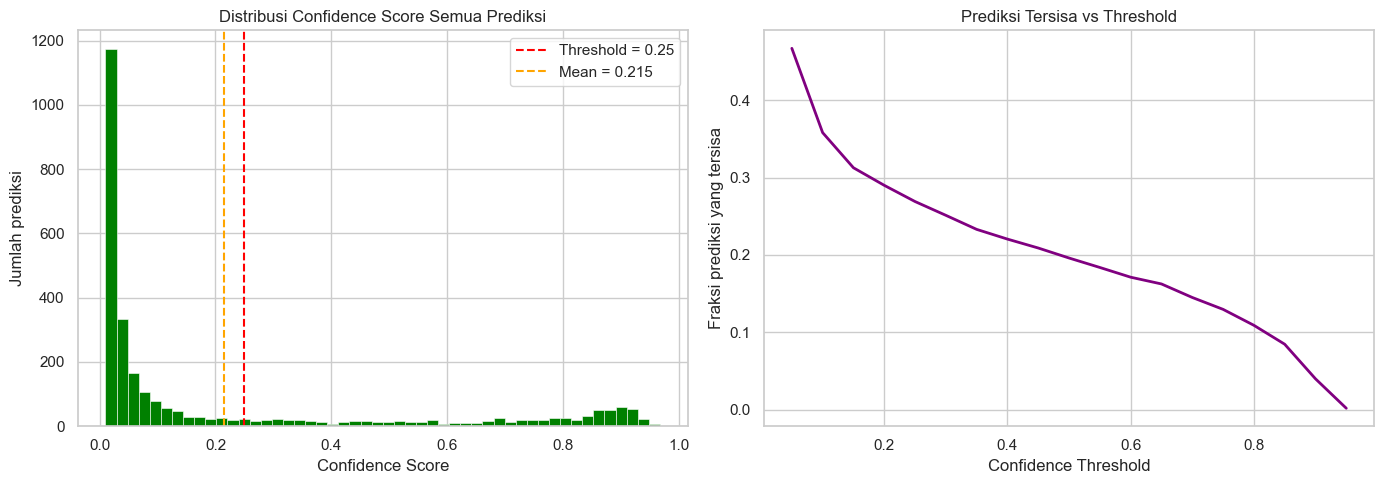

Statistik confidence score:
  Mean conf     : 0.2145
  Median conf   : 0.0429
  Conf ≥ 0.25   : 26.9% prediksi dipertahankan
  Conf ≥ 0.50   : 19.6%
  Conf ≥ 0.75   : 13.0%


In [15]:
all_confs = []

for img_path in test_images[:200]:
    result = model.predict(
        source=str(img_path),
        conf=0.01,          # Ambil semua prediksi (threshold rendah untuk analisis)
        iou=0.5,
        imgsz=IMGSZ,
        device=DEVICE,
        verbose=False
    )[0]
    if result.boxes is not None and len(result.boxes) > 0:
        confs = result.boxes.conf.cpu().numpy()
        all_confs.extend(confs.tolist())

all_confs = np.array(all_confs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram confidence
ax = axes[0]
ax.hist(all_confs, bins=50, color='green', edgecolor='white', linewidth=0.4)
ax.axvline(0.25, color='red', linestyle='--', linewidth=1.5, label='Threshold = 0.25')
ax.axvline(all_confs.mean(), color='orange', linestyle='--', linewidth=1.5,
           label=f'Mean = {all_confs.mean():.3f}')
ax.set_xlabel('Confidence Score')
ax.set_ylabel('Jumlah prediksi')
ax.set_title('Distribusi Confidence Score Semua Prediksi')
ax.legend()

# Precision-Recall vs Threshold
# Gunakan PR curve dari Ultralytics results (sudah digenerate oleh model.val())
ax = axes[1]
eval_dir = EVAL_DIR
pr_img = eval_dir / 'PR_curve.png'
if pr_img.exists():
    pr = Image.open(pr_img)
    ax.imshow(pr)
    ax.axis('off')
    ax.set_title('Precision-Recall Curve (dari Ultralytics)')
else:
    thresholds = np.arange(0.05, 1.0, 0.05)
    above_thresh = [(all_confs >= t).mean() for t in thresholds]
    ax.plot(thresholds, above_thresh, color='purple', linewidth=2)
    ax.set_xlabel('Confidence Threshold')
    ax.set_ylabel('Fraksi prediksi yang tersisa')
    ax.set_title('Prediksi Tersisa vs Threshold')

plt.tight_layout()
plt.savefig(str(EVAL_DIR / 'confidence_analysis.png'), dpi=100)
plt.show()

print(f'Statistik confidence score:')
print(f'  Mean conf     : {all_confs.mean():.4f}')
print(f'  Median conf   : {np.median(all_confs):.4f}')
print(f'  Conf ≥ 0.25   : {(all_confs >= 0.25).mean()*100:.1f}% prediksi dipertahankan')
print(f'  Conf ≥ 0.50   : {(all_confs >= 0.50).mean()*100:.1f}%')
print(f'  Conf ≥ 0.75   : {(all_confs >= 0.75).mean()*100:.1f}%')

## 4.7 Tampilkan Plot Otomatis dari Ultralytics

In [17]:
import matplotlib.image as mpimg

eval_dir = EVAL_DIR
plot_files = {
    'Confusion Matrix'    : 'confusion_matrix.png',
    'Confusion Matrix (N)': 'confusion_matrix_normalized.png',
    'PR Curve'            : 'PR_curve.png',
    'F1 Curve'            : 'F1_curve.png',
}

available = [(name, eval_dir / fname) for name, fname in plot_files.items()
             if (eval_dir / fname).exists()]

if available:
    n = len(available)
    fig, axes = plt.subplots(1, n, figsize=(7*n, 6))
    if n == 1:
        axes = [axes]
    for ax, (name, path) in zip(axes, available):
        img = mpimg.imread(path)
        ax.imshow(img)
        ax.set_title(name, fontsize=11)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(str(EVAL_DIR / 'evaluation_plots_combined.png'), dpi=100)
    plt.show()
else:
    print('Plot Ultralytics belum tersedia di direktori eval.')

Plot Ultralytics belum tersedia di direktori eval.


## 4.8 Analisis Hard Cases (Kasus Tersulit)

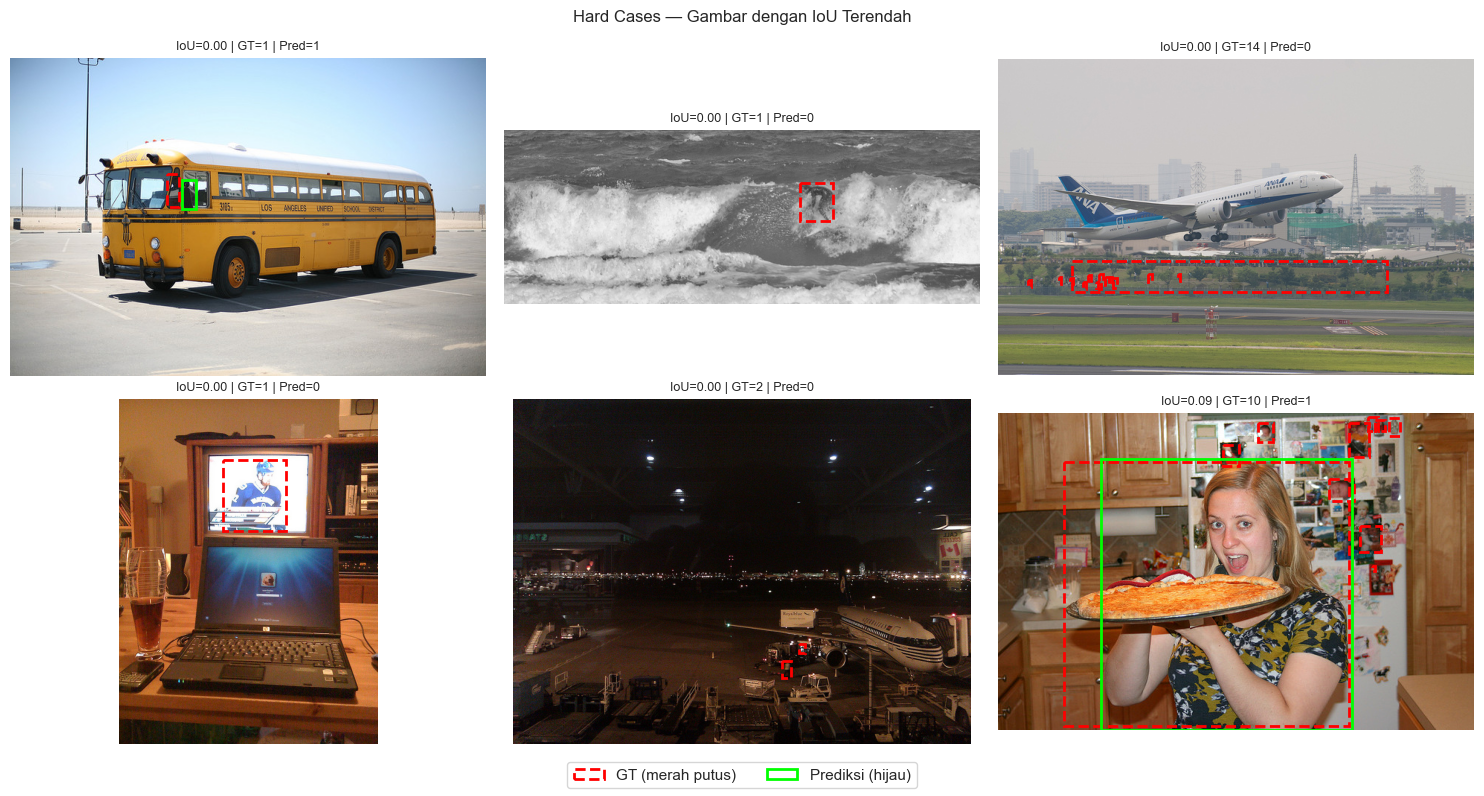

In [19]:
# Temukan gambar dengan IoU terendah (model paling kesulitan)
image_min_iou = []

for img_path in test_images[:100]:
    lbl_path = test_lbl_dir / (img_path.stem + '.txt')
    if not lbl_path.exists():
        continue

    result = model.predict(
        source=str(img_path), conf=CONF_THRESH, iou=IOU_THRESH,
        imgsz=IMGSZ, device=DEVICE, verbose=False
    )[0]

    img = Image.open(img_path)
    img_w, img_h = img.size

    gt_boxes = []
    with open(lbl_path) as f:
        for line in f:
            cls, xc, yc, wn, hn = map(float, line.strip().split())
            gt_boxes.append([(xc-wn/2)*img_w, (yc-hn/2)*img_h,
                              (xc+wn/2)*img_w, (yc+hn/2)*img_h])

    if not gt_boxes or result.boxes is None or len(result.boxes) == 0:
        # False negative total
        image_min_iou.append((img_path, 0.0, len(gt_boxes), 0))
        continue

    pred_boxes = result.boxes.xyxy.cpu()
    gt_tensor  = torch.tensor(gt_boxes, dtype=torch.float32)
    iou_matrix = box_iou(gt_tensor, pred_boxes)
    mean_iou   = iou_matrix.max(dim=1).values.mean().item()
    image_min_iou.append((img_path, mean_iou, len(gt_boxes), len(result.boxes)))

# Sort berdasarkan IoU terendah
image_min_iou.sort(key=lambda x: x[1])
hard_cases = image_min_iou[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Hard Cases — Gambar dengan IoU Terendah', fontsize=12)

for ax, (img_path, mean_iou, n_gt, n_pred) in zip(axes.flat, hard_cases):
    result = model.predict(
        source=str(img_path), conf=CONF_THRESH, iou=IOU_THRESH,
        imgsz=IMGSZ, device=DEVICE, verbose=False
    )[0]
    img = Image.open(img_path).convert('RGB')
    img_w, img_h = img.size
    ax.imshow(img)
    # GT boxes (merah)
    lbl_path = test_lbl_dir / (img_path.stem + '.txt')
    with open(lbl_path) as f:
        for line in f:
            cls, xc, yc, wn, hn = map(float, line.strip().split())
            x1=(xc-wn/2)*img_w; y1=(yc-hn/2)*img_h
            ax.add_patch(patches.Rectangle((x1,y1),wn*img_w,hn*img_h,
                         linewidth=2, edgecolor='red', facecolor='none', linestyle='--'))
    # Pred boxes (hijau)
    if result.boxes is not None:
        for box in result.boxes.xyxy.cpu().numpy():
            ax.add_patch(patches.Rectangle((box[0],box[1]),box[2]-box[0],box[3]-box[1],
                         linewidth=2, edgecolor='lime', facecolor='none'))
    ax.set_title(f'IoU={mean_iou:.2f} | GT={n_gt} | Pred={n_pred}', fontsize=9)
    ax.axis('off')

plt.figlegend(['GT (merah putus)', 'Prediksi (hijau)'], loc='lower center', ncol=2)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(str(EVAL_DIR / 'hard_cases.png'), dpi=100)
plt.show()

## 4.9 Ringkasan Evaluasi Final

In [20]:
print('=' * 55)
print('        RINGKASAN EVALUASI FINAL — TEST SET')
print('=' * 55)
print(f'mAP@0.5         : {map50:.4f}  | Target: ≥ 0.60 | {"✓" if map50 >= 0.60 else "✗"}')
print(f'mAP@0.5:0.95    : {map5095:.4f}')
print(f'Precision       : {precision:.4f}')
print(f'Recall          : {recall:.4f}')
print(f'F1 Score        : {f1:.4f}')
print(f'Mean IoU        : {all_ious.mean():.4f}')
print(f'IoU ≥ 0.5       : {(all_ious >= 0.5).mean()*100:.1f}%')
print(f'Avg confidence  : {all_confs[all_confs >= 0.25].mean():.4f}  (conf ≥ 0.25)')
print('=' * 55)

if map50 < 0.60:
    print('\n→ mAP belum mencapai target. Lanjutkan ke 05_tuning.ipynb')
else:
    print('\n→ Target tercapai! Lanjutkan ke 06_visualization.ipynb')

        RINGKASAN EVALUASI FINAL — TEST SET
mAP@0.5         : 0.7551  | Target: ≥ 0.60 | ✓
mAP@0.5:0.95    : 0.5348
Precision       : 0.7784
Recall          : 0.6536
F1 Score        : 0.7106
Mean IoU        : 0.5952
IoU ≥ 0.5       : 68.7%
Avg confidence  : 0.6723  (conf ≥ 0.25)

→ Target tercapai! Lanjutkan ke 06_visualization.ipynb


---
## ✅ Ringkasan Notebook 04

| Metrik | Nilai |
|--------|-------|
| mAP@0.5 | (lihat output) |
| mAP@0.5:0.95 | (lihat output) |
| IoU distribution | Tersimpan sebagai plot |
| Confidence distribution | Tersimpan sebagai plot |
| Hard cases | 6 gambar tersulit divisualisasikan |

**Jika target belum tercapai** → `05_tuning.ipynb`  
**Jika target tercapai** → `06_visualization.ipynb`